# UrbanFlow (No Internet)

<div class="alert alert-block alert-info""><b>This is a stand-alone Notebook for use in low resource settings. NO internet connection is necessary.</b> 

<br>
<br>

While an internet connection is **NOT** necessary you will **NEED** to have sourced an **[osm.pbf](https://wiki.openstreetmap.org/wiki/PBF_Format).**

To execute an Incompressible Fluid Flow simulation you will need to download and install [**OpenFoam**]() --*instructions just after **2. create a .OBJ file .** below*.

And to calculate a Universal Thermal Comfort Indicator (UTCI) for your own community you will **NEED** to have sourced a `POWER_Regional_Monthly_1984_2025.csv`; an extract of the `ALLSKY_SFC_SW_DWN` (All Sky Surface Shortwave Downward Irradiance) dataset.  

These can be harvested from the **[NASA Prediction Of Worldwide Energy Resources (POWER) Project](https://power.larc.nasa.gov) data [access viewer](https://power.larc.nasa.gov/data-access-viewer/).**</div>

**The purpose of this NoteBook is to walk a user through the advanced usage of *geo3D* products.**


<div class="alert alert-block alert-warning"><b>This notebook will:</b>

> **1. allow the user to create a Level-of-Detail 1 (LoD1) [3D City Model](https://en.wikipedia.org/wiki/3D_city_model).**  
>
> **2. create a .STL file .** and **[OpenFOAM]()** configuration files, with a very brief step-by-step walk-through to illustrate how to setup and execute an Incompresible Fluid Flow [**Computational Fluid Dynamics**](https://en.wikipedia.org/wiki/Computational_fluid_dynamics) Simulation with **[OpenFOAM]()**.
> > **a.** harvest the OpenFOAM result to estimate **Pedestrian Wind Comfort (PWC)** with 
> > 
> > **b.** calculate a **Universal Thermal Comfort Indicator (UTCI)** in summer and winter, and
> > 
> > **c.** lastly estimate the **Wind Chill Index** 
>
> **2. propose several [Geography and Sustainable Development Education *conversation starters*](#Section2) for Secondary and Tertiary level students**
</div>

<div class="alert alert-block alert-danger"><b></b>

***This  [UrbanFlow (No Internet)](https://github.com/AdrianKriger/geo3D/tree/main/suburb)*** ***geo3D*** processing option is meant for areas NO larger than 600 meters in diameter.

Simulations take resources *(processing power, space)* and time. The greater the number of features, in this case: buildings, the more resources and time is necessary. The purpose of this NoteBook is to provide a *taste* of what is possible.</div>

In [1]:
# load the magic
import time
import datetime
from datetime import timedelta
from zoneinfo import ZoneInfo
import tempfile

import os
import sys
from itertools import chain
import math
import requests
import overpass
import copy
import json
import numpy as np
import pandas as pd
import topojson as tp

import shapely
from shapely.geometry import Point, Polygon, MultiPolygon, shape, polygon, box 
from shapely.ops import snap, transform, unary_union
from shapely.strtree import STRtree

import pyproj
from osgeo import gdal, ogr, osr

import triangle as tr

from openlocationcode import openlocationcode as olc

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

In [2]:
#- get current working directory (notebook location)
current_dir = os.getcwd()

#- go one level up
parent_dir = os.path.dirname(current_dir)
# Add parent directory to sys.path if needed
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

#- import
import city3D
import openfoam

In [3]:
Tstart = time.time()

import warnings
warnings.filterwarnings('ignore')

**A `parameter.json` defines the path and files**.

In [4]:
jparams = json.load(open('../param/wStock_param.json'))       
#jparams = json.load(open('../param/mamre_param.json'))   
#jparams = json.load(open('../param/sRiver_param.json'))   
#jparams = json.load(open('../param/saao_param5m.json'))         

**Harvest [OpenStreetMap](https://en.wikipedia.org/wiki/OpenStreetMap)** - interogate an osm.pbf (["Protocolbuffer Binary Format"](https://wiki.openstreetmap.org/wiki/PBF_Format)) from within Jupyter and convert to .geojson.

<div class="alert alert-block alert-info"><b></b> 
    
**PLEASE SUPPLY YOUR OWN [osm.pbf](https://wiki.openstreetmap.org/wiki/PBF_Format).**  

**Either crop an area directly from [OpenStreetMap]() with the ***[official tool](https://www.openstreetmap.org/export#map=3/0.70/22.15)***, select a predefined area [from any number of providers](https://wiki.openstreetmap.org/wiki/Planet.osm), such as ***[Geofabrik](https://download.geofabrik.de)***, or...**
</div>

<div class="alert alert-block alert-success"><b></b>
    
**... download your own. Provincial extracts for South Africa are available here:** *http://download.openstreetmap.fr/extracts/africa/south_africa/*</div>

In [5]:
# Input OSM PBF file
input_pbf = "../data/CapeTown.osm.pbf"
#input_pbf = "./data/south-africa-latest.osm.pbf"

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
**Please enter a location** *--center this on your area of interest* </div>

In [6]:
center_lat, center_lon =  -33.92819, 18.44359 # wStock | wQuarter
#center_lat, center_lon = -33.93379, 18.45964 # sRiver | durham 
#center_lat, center_lon = -33.934516, 18.477391 # saao

In [7]:
def get_bbox(lat, lon, radius_m):
    # Rough approximation for WGS84
    deg_lat = radius_m / 111111.0
    deg_lon = radius_m / (111111.0 * math.cos(math.radians(lat)))
    
    return [lon - deg_lon, lat - deg_lat, lon + deg_lon, lat + deg_lat]

# Example usage
minx, miny, maxx, maxy = get_bbox(center_lat, center_lon, 300)

# 1. Initialize your custom GeoDataFrameLite with the center point
center_point = Point(center_lon, center_lat)
center_gdf = city3D.GeoDataFrameLite({
    'geometry': [center_point]
})
center_gdf.crs = "EPSG:4326"

# 2. Leverage your class's built-in pyproj database query to estimate the UTM CRS
utm_crs = center_gdf.estimate_utm_crs()

# 3. Transform to meters, buffer by 300m, and transform back to WGS84
# Note: Since .buffer() returns a standard Pandas Series, we extract the first element [.iloc[0]]
utm_gdf = center_gdf.to_crs(utm_crs)
buffered_geom_meters = utm_gdf["geometry"].iloc[0].buffer(400)

# Temporarily wrap it to use your .to_crs() method to get back to WGS84
temp_utm_gdf = city3D.GeoDataFrameLite({'geometry': [buffered_geom_meters]})
temp_utm_gdf.crs = utm_crs
circular_geom = temp_utm_gdf.to_crs("EPSG:4326")["geometry"].iloc[0]

# 4. Wrap everything cleanly into your homebred GeoDataFrameLite configuration
aoi = city3D.GeoDataFrameLite({
    'id': ["area_of_interest"],
    'lat': [center_lat],
    'lon': [center_lon],
    'geometry': [circular_geom]
})
aoi.crs = "EPSG:4326"

In [8]:
#len(geoms)

**Only harvest what we need from the osm.pbf.**

In [9]:
start = time.time()

gdal.UseExceptions()
gdal.SetConfigOption("OGR_GEOMETRY_ACCEPT_UNCLOSED_RING", "NO") 
#gdal.SetConfigOption("USE_CUSTOM_INDEXING", "NO")

# GDAL Virtual File System (VSI) to avoid writing to disk
geojson_vsimem = "/vsimem/temp.geojson"

#- GDAL VectorTranslate to extract only buildings & fix geometries
gdal.VectorTranslate(
    geojson_vsimem,                                           # Output as in-memory GeoJSON
    input_pbf,                                                # Source OSM PBF file
    format="GeoJSON",                                         # Output format
    layers=["multipolygons"],                                 # Extract only multipolygons
    options=["-where", "building IS NOT NULL", "-makevalid", 
                          "-spat", str(minx), str(miny), str(maxx), str(maxy)]  # Filter buildings & fix geometries
)

#- execute and return GeoDataFrameLite | home-baked gdf
gdf = city3D.read_vsimem_geojson("/vsimem/temp.geojson")

#- cleanup VSI Memory
gdal.Unlink(geojson_vsimem)

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:01.849845


ERROR 1: Non closed ring detected.
ERROR 1: Non closed ring detected.


In [10]:
gdf.head(2)
#len(gdf)

,amenity,building,geometry,name,office,osm_id,osm_way_id,other_tags,shop,tourism,type
0,None,commercial,"MULTIPOLYGON (((18.4461933 -33.9265241, 18.446...",None,None,13501234,None,"""addr:city""=>""Cape Town"",""addr:housename""=>""Th...",None,None,multipolygon
1,None,train_station,"MULTIPOLYGON (((18.4459821 -33.9256137, 18.446...",Woodstock Station,None,None,65768975,"""addr:city""=>""Cape Town"",""addr:suburb""=>""Woods...",ticket,None,None


In [11]:
# Convert valid strings, ignore None/NaN
def safe_convert(tag_string):
    if isinstance(tag_string, str):
        try:
            # Replace "=>" with ":" and fix newlines
            formatted_string = "{" + tag_string.replace("=>", ":").replace("\n", " ") + "}"
            return json.loads(formatted_string)  # Parse safely
        except json.JSONDecodeError:
            return {}  # Return empty dict on failure
    return {}  # Return empty dict if NaN or None

# Apply conversion function
gdf["tags"] = gdf["other_tags"].apply(safe_convert)

# Extract values safely - Normalize the 'tags' column to create a new DataFrame
tags_df = pd.json_normalize(gdf['tags'])
# Join the new columns back to the original GeoDataFrame
gdf = pd.concat([gdf, tags_df], axis=1)
# (Optional) Drop the original 'tags' column
gdf = gdf.drop(columns=['other_tags'])

# Ensure a single 'osm_id' column
if 'osm_id' in gdf.columns:
    if 'osm_way_id' in gdf.columns:
        gdf['osm_id'] = [o if pd.notna(o) else w 
                         for o, w in zip(gdf['osm_id'], gdf['osm_way_id'])]
        gdf = gdf.drop(columns=['osm_way_id'])
elif 'osm_way_id' in gdf.columns:
    gdf = gdf.rename(columns={'osm_way_id': 'osm_id'})

gdf = gdf[gdf.geometry.apply(lambda x: x.within(shapely.unary_union(aoi.geometry)))]
gdf.crs = "EPSG:4326"

gdf.head(2)

,amenity,building,geometry,name,office,osm_id,shop,tourism,type,tags,...,service:bicycle:repair,service:bicycle:second_hand,service:bicycle:tools,layer,research,parking,animal,animal_boarding,unisex,residential
0,None,commercial,"MULTIPOLYGON (((18.4461933 -33.9265241, 18.446...",None,None,13501234,None,None,multipolygon,"{'addr:city': 'Cape Town', 'addr:housename': '...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,None,train_station,"MULTIPOLYGON (((18.4459821 -33.9256137, 18.446...",Woodstock Station,None,65768975,ticket,None,None,"{'addr:city': 'Cape Town', 'addr:suburb': 'Woo...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
ts = gdf[gdf['building'].notna()]
#len(ts)
print('\n', len(ts), "buildings have been harvested from", input_pbf)


 314 buildings have been harvested from ../data/CapeTown.osm.pbf


In [13]:
ts.head(2)

,amenity,building,geometry,name,office,osm_id,shop,tourism,type,tags,...,service:bicycle:repair,service:bicycle:second_hand,service:bicycle:tools,layer,research,parking,animal,animal_boarding,unisex,residential
0,None,commercial,"MULTIPOLYGON (((18.4461933 -33.9265241, 18.446...",None,None,13501234,None,None,multipolygon,"{'addr:city': 'Cape Town', 'addr:housename': '...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,None,train_station,"MULTIPOLYGON (((18.4459821 -33.9256137, 18.446...",Woodstock Station,None,65768975,ticket,None,None,"{'addr:city': 'Cape Town', 'addr:suburb': 'Woo...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# basic cleaning to harvest building=* (no building:part=*) and building=levels tags only

#- we only want buildings with =levels data
ts = (
    ts.dropna(subset=['building:levels'])
      .assign(**{'building:levels': pd.to_numeric(ts['building:levels'], errors='coerce')})
      .query("`building:levels` != 0")
)

#- without building:part
ts = ts[ts.get("building:part").isnull()] if "building:part" in ts else ts
#ts = ts.explode()
print('\n\033[1m', jparams['FocusArea'], 'has \033[0m', len(ts), 'buildings')


 Woodstock has  306 buildings


In [15]:
# have a look
ts.tail(2)

,amenity,building,geometry,name,office,osm_id,shop,tourism,type,tags,...,service:bicycle:repair,service:bicycle:second_hand,service:bicycle:tools,layer,research,parking,animal,animal_boarding,unisex,residential
318,toilets,toilets,"MULTIPOLYGON (((18.440959 -33.9279434, 18.4410...",None,None,1304482079,None,None,None,"{'building:levels': '1', 'unisex': 'yes'}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN
319,None,residential,"MULTIPOLYGON (((18.4456281 -33.9273695, 18.445...",None,None,1304501184,None,None,None,"{'addr:city': 'Cape Town', 'addr:housename': '...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,student


In [16]:
#- coordinate reference system
ts.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<img src="../data/proj.png" alt="proj" width="550" align="right"/>
<br>
<br>

We need the ***Projected*** Coordinate Reference System.  

In [17]:
#- estimate utm: internal geopandas function
ts.estimate_utm_crs()

<Projected CRS: EPSG:32734>
Name: WGS 84 / UTM zone 34S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 18°E and 24°E, southern hemisphere between 80°S and equator, onshore and offshore. Angola. Botswana. Democratic Republic of the Congo (Zaire). Namibia. South Africa. Zambia.
- bounds: (18.0, -80.0, 24.0, 0.0)
Coordinate Operation:
- name: UTM zone 34S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
**Fill in the proper `espg` in the _`cell`_ below** </div>

In [18]:
#- fill <Projected CRS: EPSG:32734> from above here epsg = EPSG:32734
epsg = 'EPSG:32734'

In [19]:
#project blds
ts = ts.to_crs(epsg)
#project aoi
aoi = aoi.to_crs(epsg)

**Now we process.**  

In [20]:
aoibuffer = aoi.copy()

def buffer01(row):
    with np.errstate(invalid='ignore'):
        return row.geometry.buffer(150, cap_style=1, join_style=2)

aoibuffer['geometry'] = aoibuffer.apply(buffer01, axis=1)
    
#- suppose 'aoi' is your GeoDataFrameLite or list of geometries
geoms = aoibuffer['geometry'].tolist()
#- combine all geometries into a single union
combined_geom = shapely.unary_union(geoms)                # returns Polygon or MultiPolygon
#- compute bounding box
minx, miny, maxx, maxy = combined_geom.bounds

extent = [minx - 250, miny - 250,
          maxx + 250, maxy + 250]

**Now the DEM**  
*one is available at [raster](https://github.com/AdrianKriger/geo3D/suburb/tree/main/raster)*

In [21]:
gdal.SetConfigOption("GTIFF_SRS_SOURCE", "GEOKEYS")
gdal.UseExceptions() 

# set the path and nodata
OutTile = gdal.Warp(jparams['projClip_raster'], 
                    jparams['in_raster'],
                    dstSRS=epsg,
                    srcNodata = jparams['nodata'],
                    #-  dstNodata = 0,
                    #-- outputBounds=[minX, minY, maxX, maxY]
                    outputBounds = [extent[0], extent[1], extent[2], extent[3]])
OutTile = None 

In [22]:
#- convert raster to XYZ in-memory

#- virtual in-memory path
xyz_mem_path = "/vsimem/temp_xyz.xyz"  
gdal.Translate(xyz_mem_path, jparams['projClip_raster'], format="XYZ")  

#- read XYZ from GDAL's in-memory file
xyz_vsimem = gdal.VSIFOpenL(xyz_mem_path, "rb")
xyz_bytes = gdal.VSIFReadL(1, gdal.VSIStatL(xyz_mem_path).size, xyz_vsimem)
gdal.VSIFCloseL(xyz_vsimem)
#- cleanup in-memory file
gdal.Unlink(xyz_mem_path) 

0

**prepare to harvest elevation**

In [23]:
# set the path to the projected, cliped elevation
src_filename = jparams['projClip_raster']

src_ds = gdal.Open(src_filename) 
gt_forward = src_ds.GetGeoTransform()
rb = src_ds.GetRasterBand(1)

**Buildings**

In [24]:
#- simplify geometry
ts = city3D.GeoDataFrameLite(ts)
geojson_dict = json.loads(ts.to_json())

for feat in geojson_dict["features"]:
    if feat.get("type") is None:
        feat["type"] = "multipolygon"
    if feat.get("geometry") is None:
        feat["geometry"] = {"type":"MultiPolygon","coordinates":[]}

topo = tp.Topology(geojson_dict, prequantize=False, winding_order='CCW_CW')
simplified_geojson = topo.toposimplify(0.25).to_geojson()

ts = city3D.GeoDataFrameLite.from_json(simplified_geojson)
ts.crs = epsg

In [25]:
# prepare to plot (more buildings = more time) 
start = time.time()

ts_copy = ts.copy()

geoms = ts_copy["geometry"].tolist()
tree = STRtree(geoms)

#- Query the tree for overlaps
# This returns two arrays: 'i' (index in geoms we are checking) and 'j' (index in the tree it overlapped with)
# Vectorized query: fastest way to find overlaps
i, j = tree.query(geoms, predicate="overlaps")

#- filter self-matches and get unique indices of all involved buildings
mask = i != j
overlap_idx = set(i[mask])

new_df1 = ts_copy.iloc[list(overlap_idx)].reset_index(drop=True)

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:00.011605


**Plot**

*Browse the saved `'./data/topologyFig'` at your leisure*

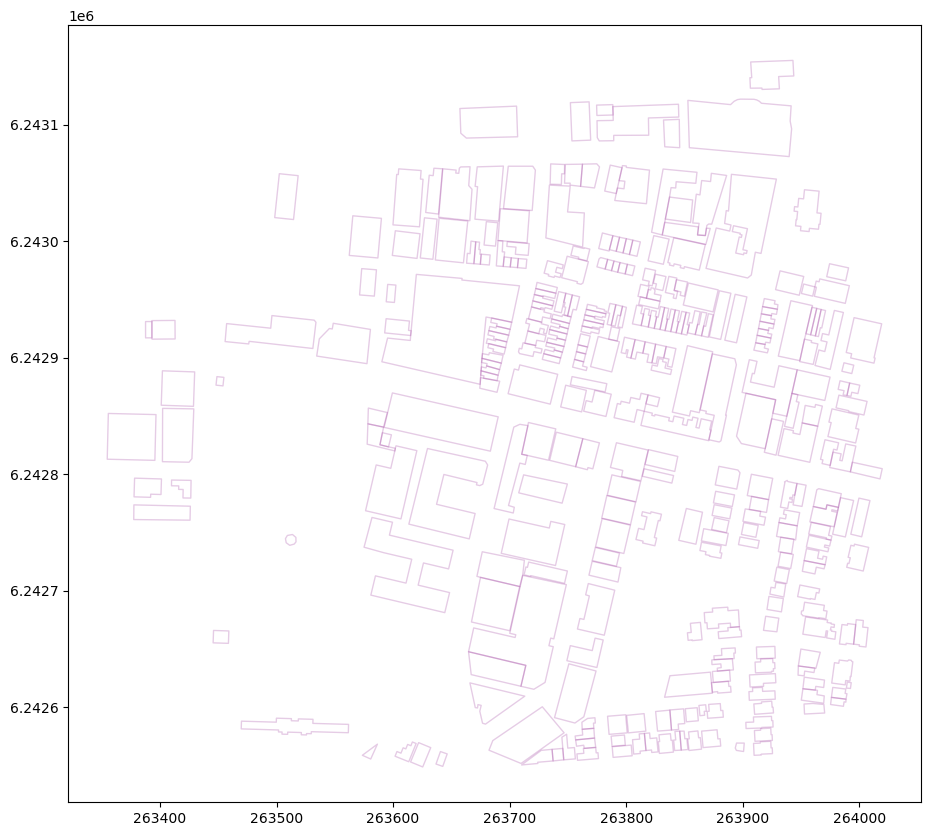

In [26]:
#- plot

def plot_geometries(df, ax=None, facecolor='none', edgecolor='purple', alpha=0.5):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,10))

    patches = []

    for geom in df['geometry']:
        if geom is None:
            continue

        if isinstance(geom, Polygon):
            # Exterior ring
            patches.append(MplPolygon(list(geom.exterior.coords), closed=True))
            # Interiors (holes)
            for interior in geom.interiors:
                patches.append(MplPolygon(list(interior.coords), closed=True))
        elif isinstance(geom, MultiPolygon):
            for poly in geom.geoms:
                patches.append(MplPolygon(list(poly.exterior.coords), closed=True))
                for interior in poly.interiors:
                    patches.append(MplPolygon(list(interior.coords), closed=True))

    pc = PatchCollection(patches, facecolor=facecolor, edgecolor=edgecolor, alpha=alpha)
    ax.add_collection(pc)
    ax.autoscale()
    ax.set_aspect('equal')
    return ax

# Example usage:
fig, ax = plt.subplots(figsize=(11, 11))
plot_geometries(ts_copy, ax=ax, facecolor='none', edgecolor='purple', alpha=0.2)
if len(new_df1) > 0:
    plot_geometries(new_df1, ax=ax, facecolor='none', edgecolor='red', alpha=0.5)
    
#-- save
plt.savefig('../data/topologyFig', dpi=300)
#plt.show()

|  |  |
|:--------:|:--------:|
| ![ue-error.png](../data/ue-error.png)| **Challenges will be highlight in *'Red'***|
| ![ue.png](../data/ue.png)| **or none**|
|<br /> **If you continue without fixing the challenges, the LoD1 City Model *will not be error free*.** | <br /> **Our goal is a topologically correct surface.** |

<h2><center> Please ensure the quality of the value-added product and the source data.</center></h2>

**If necessary; edit [OpenStreetMap](https://www.openstreetmap.org/about) and fix the challenge please.**

<div class="alert alert-block alert-warning"><b></b>
    
And remember.  
Many [Planet.osm mirrors](https://wiki.openstreetmap.org/wiki/Planet.osm) (like the one recommended above) release a ***fresh `.osm.pbf` EVERYDAY!***  
Give the OpenStreetMap server ***at least a day*** before attempting the process again.
    
**Alchemy is a process. Please be patient.**
</div>

<div class="alert alert-block alert-warning"><b>Calculate building height:</b> 

We assume a building level is 2.8 meters high and add another 1.3 meters (to account for the roof) and create a new `building_height` attribute .</div>

The Python code to execute the `.bldHeights` function is in the `city3D.py` script

In [27]:
# -- execute function. write geoJSON
dis = city3D.bldHeights(ts)

In [28]:
start = time.time()

dis_c = dis.copy()
dis_c.drop(dis.index[dis['building'] == 'bridge'], inplace = True)
dis_c.drop(dis.index[dis['building'] == 'roof'], inplace = True)

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:00.001845


In [29]:
print(len(dis), 'buildings have been harvested from the osm.pbf for the', jparams["FocusArea"], 'area') 

306 buildings have been harvested from the osm.pbf for the Woodstock area


In [30]:
dis_c.head(2)

,osm_id,address,building,building:levels,building:use,building:flats,beds,residential,amenity,social_facility,operator,building_height,min_height,plus_code,footprint,geometry
0,13501234,The Woodstock Exchange 66-68 Albert Road Woods...,commercial,6.0,NaN,NaN,NaN,NaN,None,NaN,Signatura,18.1,0.0,4FRW3CFW+69W,"[[(263928.922, 6243053.284), (263890.36, 62430...","POLYGON ((263928.92246 6243053.28384, 263890.3..."
1,65768975,Woodstock Station Woodstock Cape Town,train_station,3.0,NaN,NaN,NaN,NaN,None,NaN,NaN,9.7,0.0,4FRW3CFW+PFM,"[[(263906.88, 6243153.778), (263907.77, 624314...","POLYGON ((263906.880496 6243153.777931, 263907..."


**prepare the elevation for the TIN**

In [31]:
#- 
#dis_c = dis.copy()

In [32]:
#- prepare xyz (more buildings = more time)
start = time.time()

# Convert bytes to DataFrame
xyz_str = xyz_bytes.decode("utf-8")  # Decode to string

dtype_spec = {
    "x": np.float32,  # Reduce precision from float64 to float32 (saves memory)
    "y": np.float32,
    "z": np.float32
}

df = pd.read_csv(pd.io.common.StringIO(xyz_str), delimiter=" ",  header=None, 
                 names=["x", "y", "z"], dtype=dtype_spec)                     # in memory fastest

#- Create the shapely 'geometry' column directly (Vectorized) and GeoDataFrameLite | home-baked gdf
df['geometry'] = df.apply(lambda row: Point(row['x'], row['y']), axis=1) 
gdf = city3D.GeoDataFrameLite(df) 
gdf.crs = epsg

# --- cleanup ---
gdf = gdf[gdf['z'] != jparams['nodata']] 
gdf.reset_index(drop=True, inplace=True)
print(len(gdf))

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

4096
runtime: 0:00:00.051193


<div class="alert alert-block alert-warning"><b>Prepare for Triangle:</b> </div>

The Python code to execute the `city3D.functions` are in the `city3D.py` script

In [33]:
#- harvest the building vertices, combine with the elevation, create regions and segments for Triangle
coords, regions, segments = city3D.prepareTri(gdf, dis_c, aoibuffer)

**Triangle**

In [34]:
A = dict(vertices=np.array(coords), segments=np.array(segments), #holes=np.array(holes), 
         regions=np.array(regions))

# 'p'  = Triangulate the PSLG: Delauney triangulation with segments (building outlines) as constraints.
# 'Y' = Do NOT add Steiner points
# 'A'  = Attribute triangles with region IDs
# 'z'  = Zero-based indexing (prevents index errors)
Tr = tr.triangulate(A, 'pYAz')

In [35]:
#- the vertices 
final_verts_2d = Tr['vertices']

#- round to 3 decimals to match your get_pt_idx rounding
z_cache = {(row.x, row.y): row.z for row in gdf.itertuples()}

## -- we triangulate in 2D and project into 3D space. the vertices of the building outlines need a 'z'-value
final_verts_3d = []
for x, y in final_verts_2d:
    x_r, y_r = x, y
    
    # 2. Check if we already have the Z value in our GDF points
    if (x_r, y_r) in z_cache:
        z = z_cache[(x_r, y_r)]
    else:
        # 3. Only query the raster if the point is a new vector/Steiner vertex
        z = float(city3D.rasterQuery2(x, y, gt_forward, rb))

    final_verts_3d.append([x, y, z])

final_verts_3d = np.array(final_verts_3d)

#s- eparate triangles by their Region ID for CityJSON
tris = Tr['triangles']
tri_attr = Tr['triangle_attributes'].flatten()

**CityJSON**

In [36]:
#- 
minz = gdf['z'].min()
maxz = gdf['z'].max()

<div class="alert alert-block alert-warning"><b>create CityJSON</b> </div>

The Python code to execute the `.output_cityjson` function is in the `city3D.py` script

In [37]:
# -- execute function. create CityJSON
crs = epsg[5:]

city3D.output_cityjson(extent, minz, maxz, tris, tri_attr, final_verts_3d, dis, jparams, gt_forward, rb, crs)

<div class="alert alert-block alert-info"><b></b> 

**Go over to [Ninja the online CityJSON viewer](https://ninja.cityjson.org/#) and explore!**

</div>

**You are welcome to further investigate the quality of a 3D Model.**

**The [val3dity](http://geovalidation.bk.tudelft.nl/val3dity/) web app will test CityJSON geometric primitives.**

**If you parse the result of this notebook through [val3dity](http://geovalidation.bk.tudelft.nl/val3dity/) it will return a report with an invalid [TINRelief](https://www.cityjson.org/specs/1.1.1/#tinrelief) and error.**

|  |  | 
| :---: | :---: |
| **This particular area contains Buildings with courtyards. The courtyards** (polygons) **are islands of terrain disconnected from the *larger* TINRelief** (shell); **thus the error<sup>*</sup>.**|![iso19107_error.jpg](../data/iso19107_error.jpg) |

<sup>*<sub> ***Don't take my word for it. Test and see for yourself!*** `saao_param.json` (South African Royal Observatory, Cape Town) will produce a 100% topologically correct [Open Geospatial Consortium (OGC)](https://www.ogc.org/standard/citygml/) standard LoD1 3D model that conforms to the [ISO 19107 spatial schema for 3D primatives](https://www.iso.org/standard/66175.html) *[connecting and planar surfaces, correct orientation of the surfaces and watertight volumes]*</sub>

<div class="alert alert-block alert-warning"><b>NOW</b><br><br>


***To understand the value and usefulness of a 3D City Model***; parse the result of this Notebook through [CityJSONspatialDataScience.ipynb](https://github.com/AdrianKriger/geo3D/blob/main/CityJSONspatialDataScience.ipynb) to workthrough an example of:  
- population estimation and
- a calculation of [**Building Volume per Capita**](https://www.researchgate.net/publication/343185735_Building_Volume_Per_Capita_BVPC_A_Spatially_Explicit_Measure_of_Inequality_Relevant_to_the_SDGs), and
- estimate the [**Annual Average Solar** *(photovoltaic)* **Potential**](https://www.worldbank.org/en/topic/energy/publication/solar-photovoltaic-power-potential-by-country), per home.
</div>

***As always; you are welcome to raise an issue. I depend on you to help me improve.***

<a id='Section2'></a>

In [38]:
Tend = time.time()
print('runtime:', str(timedelta(seconds=(Tend - Tstart)))) #previous [2023] sRiver: 0:02:12.004094 | wStock: 07:09:57

runtime: 0:00:04.435698


## 2. OBJ 

<div class="alert alert-block alert-warning"><b>create .OBJ</b> for openFOAM</div>


In [39]:
#- .obj
start = time.time()

x_off, y_off, max_bld_h, max_z_abs, buildingsOBJ = city3D.exportOBJ(dis, extent, "../result/wStockNoInternet.obj")

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:00.249088


In [40]:
src_ds = None

## 3. openFOAM Case Writer

<div class="alert alert-block alert-warning"><b>
    
</b> create folders and files for **[openFOAM](https://www.openfoam.com)**</div>

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the details about your community: 

 **`nu`** (viscosity)**:** `sea-level` or `elevated` (above 800m)  

 and 
 
 **`z0`** (roughness)**<sup>*<sub>:** can be `water, open` (flat or rolling plains), `rural` (scattered houses surrounded by scrubland / agriculture), `village, town and suburb` (includes forests), `urban suburb and city` (areas with *tall-ish* buildings) or `metro` (Skyscrapers/Metropolitan areas)
</div>

<sup>*<sub> *These are [The European Wind Atlas (EWA)]() standards for roughness; which define the land surface's impact on wind speed, typically represented by the roughness length ($z_0$), and measures the height at which wind speed theoretically becomes zero.*</sub>

In [41]:
nu = 'sea-level'
z0 = 'urban suburb and city'
#z0 = 'village, town and suburb'

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the details about the wind: 

 **`xx_inlet`:** wind speed in m/s  
 **`xx_deg`:** wind direction in degrees
    
</div>

*-you might want do this twice. once for summer and once for winter.*

In [42]:
#- speed     ~ durham: summer 11.1, winter 9.8 | wQuarter: summer 7.2, winter 6.9 | mamre: summer 13.8, winter 7.2
#- direction ~ durham: summer 135, winter 315  | wQuarter: summer 210, winter 340  | mamre: summer 190, winter 0

#- summer
Su_inlet = 7.2
Su_deg = 210 

#- winter
Wu_inlet = 6.9
Wu_deg = 340

<div class="alert alert-block alert-warning"><b>SIMULATION STRATEGIES</b><br><br>

With ***geo3D***; [OpenFOAM](https://www.openfoam.com) configuration files come in two flavours *(two simulation options)*. There are other [higher-order solvers](https://cfd.direct/openfoam/features/turbulence-modelling/) but ***geo3D*** only creates [openFOAM](https://www.openfoam.com) configuration files for two:

- **[RANS (Reynolds-Averaged Navier-Stokes)](https://en.wikipedia.org/wiki/Reynolds-averaged_Navier–Stokes_equations)** and
- **[URANS (Unsteady RANS)]()**

These both use Reynolds-Averaged approaches to model turbulence.  
While they use the same physics-based turbulence models, such as $𝑘 − 𝜔$ SST or $𝑘 − 𝜖$, **they differ in how they treat time and capturing fluctuations.** 
</div>

| Feature | [RANS]()  | [URANS (Unsteady RANS)]() |
|:------|:------------------------:|:----------------------------:|
| **Objective** | Solves for the time-independent mean flow. | Captures large-scale unsteady patterns over time |
| **Solvers** | `simpleFoam` | `pimpleFoam` |
| **Effectiveness** | Will often, especially in a complex urban environment, NOT converge | Good. |
| **Computational Cost** | Lower; solves for a single converged state <br /> Will execute within **10 to 45 minutes**| Higher; solves many iterations for each time step <br /> The **[URANS]()** solver will typically take **2 to 4 hours**| 
| **When to execute** | Preliminary site analysis and rapid visualisation | Detailed and finescale analysis that includes vortex shedding and gustiness | 

<div class="alert alert-block alert-warning"><b></b>

The RANS solver is efficient but will often NOT capture the behaviour of the wind realistically --*wind doesn't just flow; it pulses and swirls*.  

Nevertheless; for the purposes of ***geo3D*** the [RANS]() solver is more than enough.  
The **urbanFlow.ipynb** component of ***geo3D*** provides a taste of what is possible... but you are welcome to interogate your community with a higher-order solver.    
</div>

**Summer**

In [43]:
#- openfoam configuration files.

openfoam.write_openfoam_case('../openfoam/wStock/rans/summer/', extent, x_off, y_off, max_bld_h, 
                              buildingsOBJ, nu, z0, 
                              Su_inlet, Su_deg, 
                              mode='RANS')

**Winter**

In [44]:
#- openfoam configuration files.

openfoam.write_openfoam_case('../openfoam/wStock/rans/winter/', extent, x_off, y_off, max_bld_h, 
                              buildingsOBJ, nu, z0, 
                              Wu_inlet, Wu_deg,
                              mode='RANS')

## 3. Simulation

<div class="alert alert-block alert-info"><b>These analysis expect the user to have some basic knowledge about the environment under inquiry / investigation</b> </div>

We will now very briefly walk-through a [**Incompressible Fluid Flow Analysis**](https://en.wikipedia.org/wiki/Incompressible_flow) with [OpenFOAM](https://www.openfoam.com) *--so that you can do your own community*.  

Please have a look at [xxx](xxx).


<div class="alert alert-block alert-success"><b> DO NOT BE INTIMIDATED </b>  </div>

| Step | [Windows (WSL2 + Ubuntu)](https://openfoam.org/download/windows/)  | [macOS (Multipass + Ubuntu)](https://openfoam.org/download/macos/) |
|:------|:------------------------:|:----------------------------:|
|  | Run Ubuntu via Windows Subsystem for Linux (WSL2) | Run Ubuntu via Canonical Multipass virtual machine |
| **1 — Open terminal** | Open Windows Terminal or PowerShell | Open macOS terminal: *Launchpad → terminal* |
| **2 — Install WSL2 or Multipass** | run: `wsl --install -d Ubuntu-22.04` | Download [Multipass for MacOS](https://canonical.com/multipass/install) <br />then install: `*.pkg` |
| **3 — Start Ubuntu** | Type `wsl` in terminal or open "Ubuntu" from Start | `multipass launch -c 6 -m 4G -d 20G -n openfoam jammy` |
| **4 — Open Ubuntu shell** | A Linux (Bash) terminal opens automatically | `multipass shell openfoam` |
| **5 — Add OpenFOAM repository** | `sudo sh -c "wget -O - https://dl.openfoam.org/gpg.key > /etc/apt/trusted.gpg.d/openfoam.asc"`<br /> then `sudo add-apt-repository http://dl.openfoam.org/ubuntu` | Same as Windows (run inside the Multipass shell) |
| **6 — Update package list** | `sudo apt update` | `sudo apt update` |
| **7 — [Install OpenFOAM 13](https://openfoam.org/download/13-ubuntu/)** | `sudo apt -y install openfoam13` | `sudo apt -y install openfoam13` |
| **8 — Configure user environment** | `echo ". /opt/openfoam13/etc/bashrc" >> ~/.bashrc` <br /> then then `source ~/.bashrc` | Similar to Windows (inside the Multipass shell)  <br /> `echo ". /opt/openfoam13/etc/bashrc" >> ~/.bashrc`<br /> then `source ~/.bashrc` |
| **9 — Verify installation** | `simpleFoam -help` (or `foamRun -help`) | `simpleFoam` -help (or `foamRun -help`) |
| | | |
|**10 — Get started** | mount your working folder to Ubuntu. <br /> If your work is at `C:\geo3DopenFoam` then<br /> `ln -s /mnt/c/geo3DopenFoam ~/geo3DopenFoam` | mount your working folder to Ubuntu. <br /> If your work is at `~\geo3DopenFoam` then<br /> `multipass mount ~/geo3DopenFoam openfoam:/home/ubuntu/geo3DopenFoam`|
| **11 — Navigate into working folder** | `cd ~/geo3DopenFoam` <br /> then `cd your_case_folder` followed by <br /> `pwd` <br /> and look `ls -l` | `cd /home/ubuntu/OpenFOAM/ubuntu-v13/run/your_case_folder` <br /> followed by `pwd` <br /> and look `ls -l` |
| **12 — Execute (mesh + simulation)** | Same as macOS | i. `blockMesh`, <br /> ii. `surfaceFeatures`, <br /> iii. `surfaceCheck constant/geometry/buildings.obj \| tee surfaceCheck_$(date +%Y%m%d_%H%M).log`, <br /> iv. `snappyHexMesh`,<br />  v. `checkMesh \| tee checkMesh_$(date +%Y%m%d_%H%M).log`, and finally<br /> vi. `foamRun -solver incompressibleFluid \| tee foamRun_$(date +%Y%m%d_%H%M).log`, <br />  v. `foamPostProcess -time 1000:`|
| **13 — Shut it Down** | `exit` | `exit` then<br />`multipass stop openfoam` |



<div class="alert alert-block alert-warning"><b>Post processing results</b><br><br>

The last command (**12 — Execute (mesh + simulation)** | `foamPostProcess -time 1000:`) of the [OpenFOAM](https://www.openfoam.com) process; harvests a cuttingPlane at x-meters above the ground.  
    
Extract the `/postProcessing/.../xxx.vtk` surfaces -- to the respective location: `../result/openfoam/season`.</div>

### a. Pedestrian Wind Comfort (PWC)

In this section we extract wind speeds, from the openFOAM result, at typical pedestrian height (1.2 – 1.9 m) and categorize comfort levels. We evaluate **Pedestrian Wind Comfort (PWC)** to identify ***how vertical architectural forms interact with local wind regimes***.

Modern investigations into Wind Canyons and Downwash Effects have led to localized safety indicators. The most notable of these is the **Lawson Comfort Criteria (Lawson, T.V. 1978)**. Lawson defines comfort levels (m/s) based on the probability of wind speeds exceeding specific thresholds for activities like "Sitting," "Standing," or "Walking."

**PWC provides a direct spatial measure of urban livability**. By identifying "Acceleration Zones," we can evaluate how neighborhoods perform under the local winds. This analysis builds on the work of [**(Blocken, B; et al. 2012)**](https://www.sciencedirect.com/science/article/abs/pii/S1364815211002647) and directly supports [**SDG 11: Sustainable Cities and Communities**](https://sdgs.un.org/goals/goal11) by ensuring public spaces remain safe and usable year-round.

In this section, we analyze the results from our [OpenFOAM](https://www.openfoam.com) ([**Incompressible Fluid Flow Analysis**](https://en.wikipedia.org/wiki/Incompressible_flow)) simulation framework to explore [**Tier 3 local indicators**](https://unstats.un.org/sdgs/metadata/) of wind safety at a neighbourhood level. We evaluate the performance of our site under the two most frequent wind directions:

- The **Summer South-Easter** at a punchy 40 km/h (11.1m/s)

- A zesty 35 km/h (9.8m/s) **Winter North-Wester**

In [43]:
#- will take time if the points, neighbour, owner, faces and the 1000/U files from the SimScale post-processing.zip download is large
start = time.time()

#- harvest the data
summer_path = '../result/openfoam/wStock/rans/summer'

#summerPed_dfFull, center_x_utm, center_y_utm = city3D.reconstruct_openfoam_results(summer_path, Su_deg, center_lat, center_lon, radius=400)
#summerPed_df = summerPed_dfFull[(summerPed_dfFull['Z'] >= 1.2) & (summerPed_dfFull['Z'] <= 1.9)].copy()

summerPed_df = city3D.load_openfoam_vtk(summer_path, file_name='pedestrianZone.vtk', wind_deg=Su_deg, extent=extent, radius=400.0)

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

summerPed_df.head(2)

runtime: 0:00:00.543986


,X,Y,Z,U,V,u_mag,k
0,263857.578782,6.242737e+06,1.5,0.699535,0.241789,0.761401,0.827438
1,263906.791630,6.242815e+06,1.5,-0.146293,-0.693276,0.725718,0.375224


| Ratio | Local Speed (umag) | Lawson Category (Typical) |
| :---: | :---: | :--- |
| < 0.5 | < 5.5 m/s | Sitting / Long-term |
| 0.5 - 0.75 | 5.5 - 8.3 m/s | Standing / Short-term |
| 0.75 - 1.0 | 8.3 - 11.1 m/s | Strolling / Walking |
| 1.0 - 1.2 | 11.1 - 13.3 m/s | Business Walking |
| > 1.2 | > 13.3 m/s | Uncomfortable / Distress |

In [44]:
def classify_lawson(r_ratio):
    if r_ratio < 0.5:
        return "Sitting/Long-term (Outdoor Dining)"
    elif r_ratio < 0.75:
        return "Standing/Short-term (Bus Stop)"
    elif r_ratio < 1.0:
        return "Strolling (Sightseeing)"
    elif r_ratio < 1.2:
        return "Business Walking (Commuting)"
    else:
        return "Uncomfortable/Distress"


# --- 4. LAWSON COMFORT ANALYSIS ---
# Your R calculation: u_pedestrian / u_inlet
# Since your SimScale run shows 11.1 m/s (40 km/h) as the inlet condition:
summerPed_df['R'] = summerPed_df['u_mag'] / Su_inlet
summerPed_df['lawson_class'] = summerPed_df['R'].apply(classify_lawson)

In [45]:
#-
len(summerPed_df)

3566

In [46]:
summerPed_df.head(3)

,X,Y,Z,U,V,u_mag,k,R,lawson_class
0,263857.578782,6.242737e+06,1.5,0.699535,0.241789,0.761401,0.827438,0.105750,Sitting/Long-term (Outdoor Dining)
1,263906.791630,6.242815e+06,1.5,-0.146293,-0.693276,0.725718,0.375224,0.100794,Sitting/Long-term (Outdoor Dining)
2,263631.673445,6.242740e+06,1.5,-0.547161,-0.451175,0.709255,0.097713,0.098508,Sitting/Long-term (Outdoor Dining)


In [47]:
#print(summerPed_df[['U', 'V', 'u_mag']].head())
#print(summerPed_df[['U', 'V']].dtypes)

In [48]:
summerPed_df.lawson_class.unique()

array(['Sitting/Long-term (Outdoor Dining)',
       'Standing/Short-term (Bus Stop)'], dtype=object)

In [49]:
# Get a percentage breakdown for your results section
print(summerPed_df['lawson_class'].value_counts(normalize=True) * 100)

lawson_class
Sitting/Long-term (Outdoor Dining)    99.747616
Standing/Short-term (Bus Stop)         0.252384
Name: proportion, dtype: float64


In [50]:
#utm_gdf.geometry[0].x

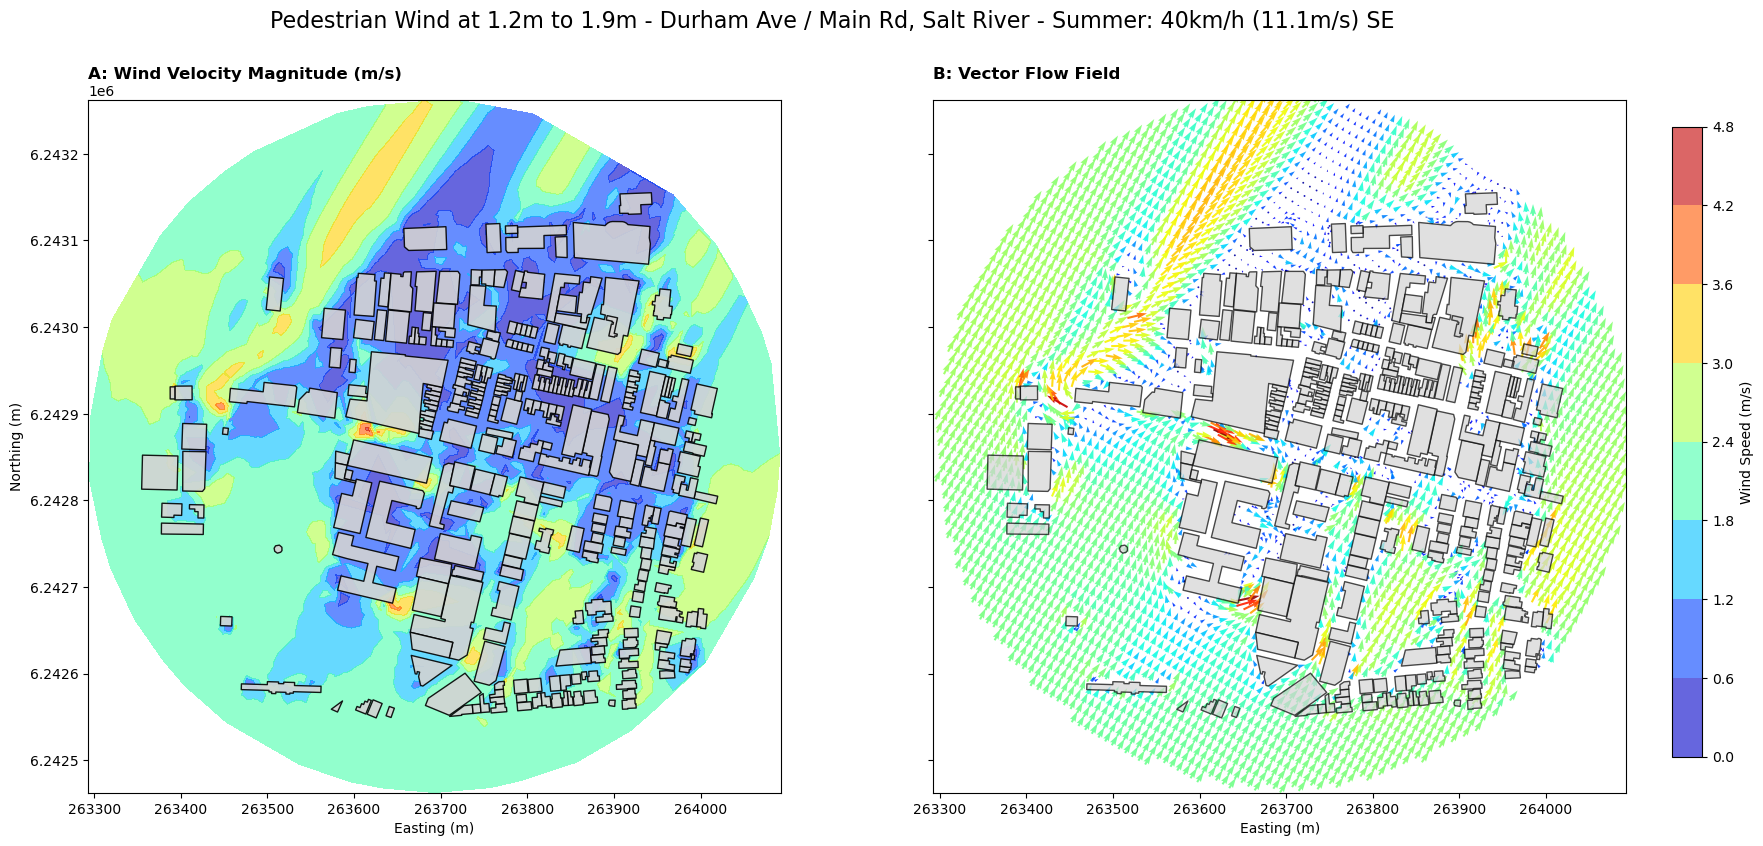

In [51]:
#- plot
fig, axes = city3D.plot_wind_analysis(summerPed_df, ts_copy, utm_gdf.geometry[0].x, utm_gdf.geometry[0].y, radius=400, 
                          title_suffix="Durham Ave / Main Rd, Salt River - Summer: 40km/h (11.1m/s) SE")
plt.show()

The **Winter North-Wester**

In [53]:
#- will take time if the points, neighbour, owner, faces and the 1000/U files is large
start = time.time()

#- harvest the data
winter_path = '../result/openfoam/wStock/rans/winter'

#winterPed_dfFull, center_x_utm, center_y_utm = reconstruct_openfoam_results(winter_path, Wu_deg, center_lat, center_lon, radius=400)
winterPed_df = city3D.load_openfoam_vtk(winter_path, file_name='pedestrianZone.vtk', wind_deg=Wu_deg, extent=extent, radius=400.0)

#winterPed_df = winterPed_dfFull[(winterPed_dfFull['Z'] >= 1.2) & (winterPed_dfFull['Z'] <= 1.9)].copy()

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

winterPed_df.head(2)

runtime: 0:00:00.518137


,X,Y,Z,U,V,u_mag,k
0,263489.184240,6.242593e+06,1.5,0.308725,-0.540327,0.622793,0.576419
1,263486.471592,6.242592e+06,1.5,0.229228,-0.597535,0.640002,0.599802


In [54]:
# --- 4. LAWSON COMFORT ANALYSIS ---
# Your R calculation: u_pedestrian / u_inlet
# Since your SimScale run shows 9.8 m/s (35 km/h) as the inlet condition:
winterPed_df['R'] = winterPed_df['u_mag'] / Wu_inlet
winterPed_df['lawson_class'] = winterPed_df['R'].apply(classify_lawson)

In [55]:
len(winterPed_df)

3586

In [56]:
winterPed_df.lawson_class.unique()

array(['Sitting/Long-term (Outdoor Dining)',
       'Standing/Short-term (Bus Stop)', 'Strolling (Sightseeing)'],
      dtype=object)

In [57]:
# Get a percentage breakdown for your results section
print(winterPed_df['lawson_class'].value_counts(normalize=True) * 100)

lawson_class
Sitting/Long-term (Outdoor Dining)    99.386503
Standing/Short-term (Bus Stop)         0.585611
Strolling (Sightseeing)                0.027886
Name: proportion, dtype: float64


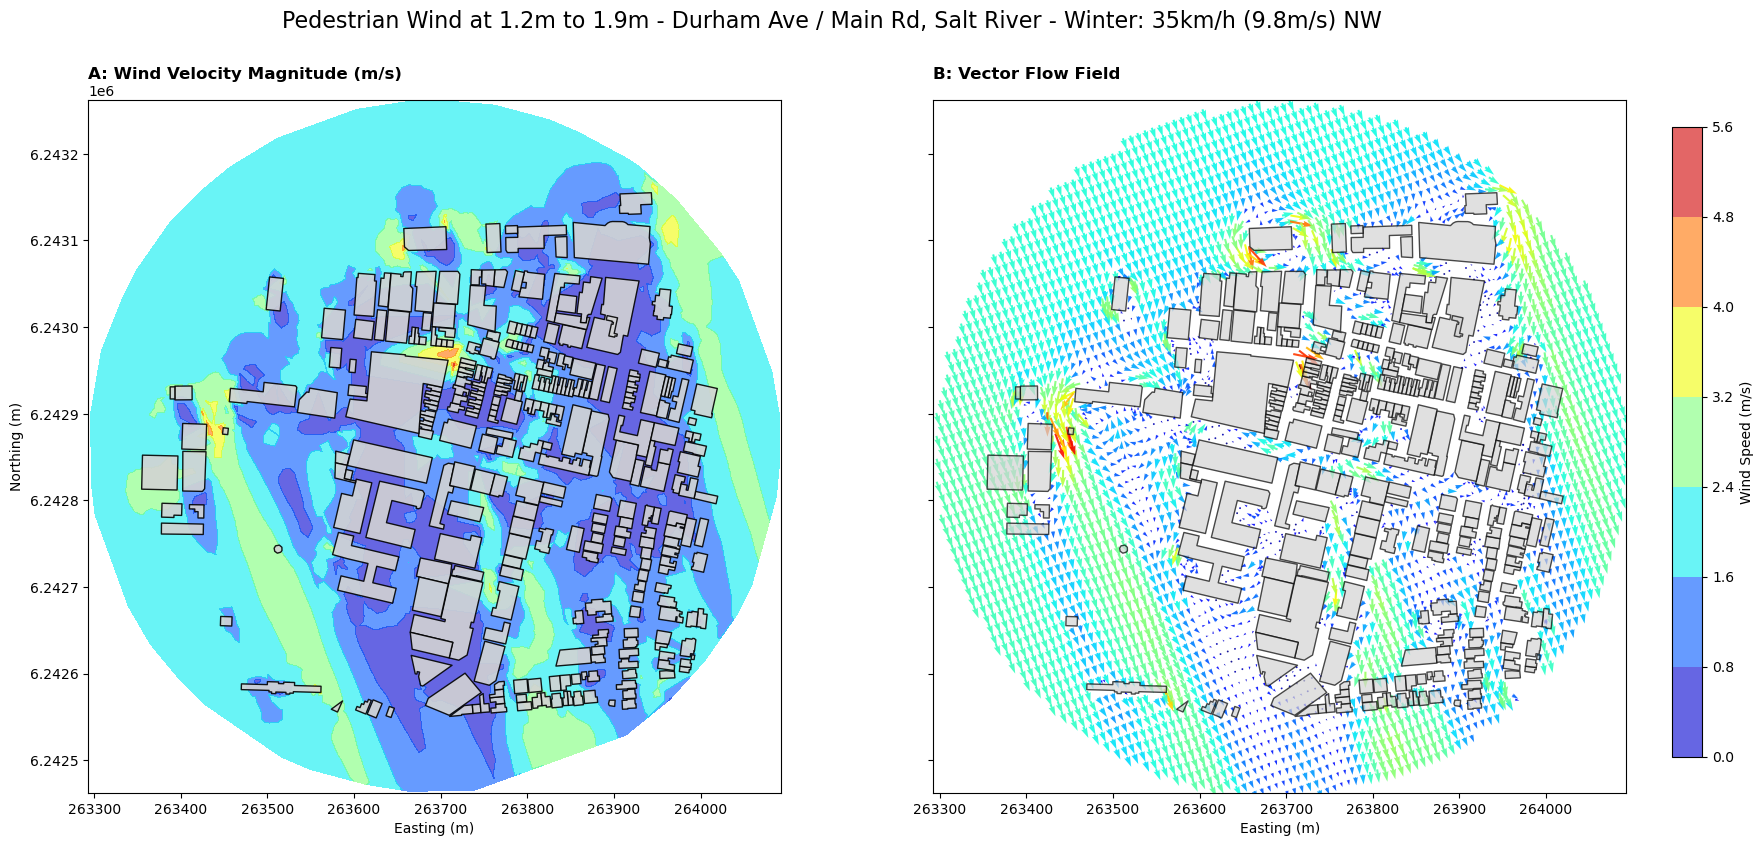

In [58]:
fig, axes = city3D.plot_wind_analysis(winterPed_df, ts_copy, utm_gdf.geometry[0].x, utm_gdf.geometry[0].y, radius=400, 
                          title_suffix="Durham Ave / Main Rd, Salt River - Winter: 35km/h (9.8m/s) NW")
plt.show()

### b. Universal Thermal Comfort Indicator (UTCI)

In this section we combine [CFD-derived](https://en.wikipedia.org/wiki/Computational_fluid_dynamics) wind fields, from the previous section, with local solar radiation and temperature data and provide a **Decoupled Thermal Analysis** to estimate summer and winter comfort. 

While traditional planning treats temperature as a uniform regional value, modern investigations into **Urban Heat Islands (UHI)** require more granular indicators. The most robust of these is the **Universal Thermal Comfort Index (UTCI)** ([**Bröde, P; et al. 2012**](https://link.springer.com/article/10.1007/s00484-011-0454-1)). UTCI is a "felt temperature" ($^\circ\text{C}$) that integrates air temperature, humidity, wind speed, and radiant heat into a single value representing human physiological stress.

UTCI provides a spatial measure of climate vulnerability, identifying "Heat Traps" and "Wind Canyons." This analysis builds on the work of [**(Fiala, D; et al. 2012)**](https://link.springer.com/article/10.1007/s00484-011-0424-7) and aligns with [**SDG 11: Sustainable Cities and Communities**](https://unstats.un.org/sdgs/metadata/).

We now utilize the decoupled simulation framework (wind velocity harvested from [OpenFoam]() CFD) and merge this with Solar Geometry: A custom Python ray-caster to determine the ***Shade vs. Sun*** status using [**NASA POWER climatology**](https://power.larc.nasa.gov).

By merging these, we explore [**Tier 3 local indicators**](https://unstats.un.org/sdgs/metadata/) of comfort at a neighborhood level, evaluating the site under seasonal extremes: 

- a **warm January Summer South-Easter** and
- the **cold July Winter North-Wester**.

<div class="alert alert-block alert-danger"><b>Technical Note on Thermal Accuracy:</b><br><br>

This [**Universal Thermal Comfort Indicator** (UTCI)]() uses a **Decoupled Thermal Analysis**. We simulate the aerodynamic wind flow via [OpenFOAM's](https://cfd.direct/openfoam/features/turbulence-modelling/) community-standard [RANS (Reynolds-Averaged Navier-Stokes)]() solver ***and combine it with*** localized solar radiation and humidity data.

While this provides an excellent approximation of pedestrian comfort, a Robust [**Heat-Transfer Simulation**](https://www.simscale.com/docs/analysis-types/heat-transfer/) would be required for a formal [Environmental Impact Assessment](https://en.wikipedia.org/wiki/Environmental_impact_assessment). Such an analysis accounts for **Surface Albedo** *(e.g., how much heat a dark road absorbs vs. a light pavement)* and **Thermal Mass** *(how buildings, the earth, etc. store heat)*</div>

<div class="alert alert-block alert-info"><b>These analysis expect the user to have some basic knowledge about the environment under inquiry / investigation</b> </div>

<div class="alert alert-block alert-warning"><b>UTCI</b><br>

The following UTCI formula is a simplified polynomial regression of the original [UTCI Fiala model](https://www.utci.org). The 'Gold Standard' reference for the full version is:

[Bröde, P., et al. (2012). **Deriving the Operational Procedure for the Universal Thermal Comfort Index (UTCI).** *International Journal of Biometeorology, 56(3), 481–494*. DOI: 10.1007/s00484-011-0454-1](https://link.springer.com/article/10.1007/s00484-011-0424-7)</div>

In [59]:
def calculate_utci_robust(ta, mrt, v, rh):
    """
    Standard UTCI calculation based on the multi-node human heat balance model.
    ta: Air Temperature (°C)
    tr: Mean Radiant Temperature (°C)
    v: Wind speed at 10m height (m/s)
    rh: Relative Humidity (%)
    """
    # Offset from air temperature
    dtp = mrt - ta
    
    # Fundamental UTCI equation constants (Approximation)
    # This captures the non-linear interaction of wind and radiation
    utci = ta + (0.344 * dtp) + (0.000185 * ta * dtp) - (0.013 * v * dtp) - \
           (0.007 * (v**2)) + (0.012 * rh) - (0.0004 * ta * rh)
           
    return round(utci, 2)

<div class="alert alert-block alert-info"><b></b> 

The polynomial approximation above is used to implement the human heat balance model within a geospatial framework. 

The specific coefficients (the numbers) are the **Standard Regression Constants** often used in tools like [ladybug_comfort](https://www.ladybug.tools/ladybug-comfort/docs/ladybug_comfort.utci.html) or the [pythermalcomfort](https://pythermalcomfort.readthedocs.io/en/latest/) Python package to avoid running the full, computationally expensive 6th-order Fortran code.

</div>

<div class="alert alert-block alert-warning"><b>Wind</b><br><br>

We already have the wind from [openFOAM](https://www.openfoam.com); all we have to do is harvest it at the appropriate height</div>

In [60]:
#- we have the wind | from the openFOAM post-process and we scale the pedestrian wind profile (1.5m) to 10m based on the roughness of the community

#summerPed_dfFull.head(2)
#summer10m_df = city3D.load_openfoam_vtk(summer_path, file_name='utciZone.vtk', wind_deg=Su_deg, extent=extent, radius=400.0)

#- these are the values from the openFOAM simulation
Z0_MAP = {
    "water": 0.0002,
    "airport_runway": 0.0024,
    "open": 0.03,
    "agri_sheltered": 0.1,
    "rural": 0.2,
    "village, town and suburb": 0.4,
    "urban suburb and city": 0.8,
    "metro": 1.2
}

z0_urban = Z0_MAP[z0]

# 2. Dynamically calculate the reduction ratio based on your exact inlet law
# Sampling z at 1.5m (pedestrian zone) and 10m (reference height)
z_pedestrian = 1.5
z_reference = 10.0

r_dynamic = np.log((z_pedestrian + z0_urban) / z0_urban) / np.log((z_reference + z0_urban) / z0_urban)

print(f"Dynamically calculated ratio (r) for z0={z0_urban}m: {r_dynamic:.4f}")
# For z0 = 0.8m, r is roughly 0.404 rather than the standard open-country 0.68!

#- calculate the equivalent open-field U10 for the UTCI empirical script
summerPed_df['U10_equivalent'] = summerPed_df['u_mag'] / r_dynamic
summerPed_df.head(2)

Dynamically calculated ratio (r) for z0=0.8m: 0.4058


,X,Y,Z,U,V,u_mag,k,R,lawson_class,U10_equivalent
0,263857.578782,6.242737e+06,1.5,0.699535,0.241789,0.761401,0.827438,0.105750,Sitting/Long-term (Outdoor Dining),1.876507
1,263906.791630,6.242815e+06,1.5,-0.146293,-0.693276,0.725718,0.375224,0.100794,Sitting/Long-term (Outdoor Dining),1.788564


<div class="alert alert-block alert-warning"><b>Relative Humidity (RH)</b><br><br>

For a *'taste'* of simulation, we don't need to model humidity changes spatially. In urban environments, RH is typically treated as a constant boundary condition for the entire site based on climate averages readily available from a number of online sources such as [TimeAndDate](https://www.timeanddate.com/weather/south-africa/cape-town/climate).

**Summer (SE Wind)**: Cape Town's South Easter is a drying wind. RH typically sits between 45% and 55%.

**Winter (NW Wind)**: This is the rain-bearing wind. RH is high, often 75% to 90%.
</div>

#### UTCI Summer

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the proper **SUMMER** Temperature: `ta` and Relative Humidity: `rh` below </div>

In [61]:
#- summer
#- temp.     ~ durham: summer 27, winter 14 | wQuarter: summer 28, winter 16 | mamre: summer 26, winter 17
#- rel. hum. ~ durham: summer 50, winter 80 | wQuarter: summer 40, winter 83 | mamre: summer 70, winter 77

Sta = 27.0
Srh = 50.0

<div class="alert alert-block alert-warning"><b>Mean Radiant Temperature (MRT)</b><br><br>

This is the most critical variable after wind. 
It represents the **sum** of all radiation hitting a person. In our simplified ***geo3D*** model, we bypass a full radiation simulation by using the **Shade vs. Sun binary**.

The **Shade Value**. If a point is shaded by a building (using the ray-caster):

$$MRT ≈ {T}_{a} $$

where; ${T}_{a}$ is (Air Temperature)

*Logic*: In the shade, the person is *shielded from direct short-wave solar radiation*, so the radiant environment is dominated by the ambient air temperature.

The **Sun Value**, If a point is exposed to the sun:

$$ MRT ≈ {T}_{a} + Δ {MRT}_{solar} $$

*Logic*: In the direct sunlight, the person is *exposed to direct short-wave solar radiation*, so we have an additional Solar MRT Offset; $Δ {MRT}_{solar}$. The value represents the additional **Radiant Heat** a person feels when standing in direct sunlight versus standing in the shade..
</div>

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the **SUMMER** `date`, `time` and `timezone` below 

list of tz time zones available: https://en.wikipedia.org/wiki/List_of_tz_database_time_zones#List
</div>

In [62]:
# Example for ..., Jan 29th at 14:00 (Summer Heat)

dt_summer = datetime.datetime(2025, 1, 29, 14, 0, tzinfo=ZoneInfo("Africa/Johannesburg"))

In [63]:
#- 
sun_azimuth, sun_altitude= city3D.get_sun_position(center_lat, center_lon, dt_summer)

print('Azimuth:', sun_azimuth)
print('Altitude:', sun_altitude)

Azimuth: 279.54385872974785
Altitude: 46.949421046388224


In [64]:
#- calculate if a person is standing in the shadows or direct sunlight
shadows = city3D.calculate_shadows(dis_c, sun_azimuth, sun_altitude)

<div class="alert alert-block alert-warning"><b></b>

Calculate the **Solar MRT Offsets** </div>

<div class="alert alert-block alert-info"><b></b> 
    
To do your own community **PLEASE SUPPLY YOUR OWN** ``POWER_Regional_Monthly_1984_2025.csv``; an extract of the `ALLSKY_SFC_SW_DWN` (All Sky Surface Shortwave Downward Irradiance) dataset.

These can be harvested from the [**NASA data access viewer**](https://power.larc.nasa.gov/data-access-viewer/) --settings: Regional, User Community: Renewable, Temporal Level: Monthly and Annually, Select Location: draw a rectangle (~state / province. NOT country), Time Extent: 1984-2025, Parameter: All Sky Surface Shortwave Downward Irradiance), Format: csv.**  

</div>

Here we interogate the [POWER Monthly Radiation](https://nasa.maps.arcgis.com/home/item.html?id=f8b59c55f66c47bba486354a122a5489) dataset. This is a global dataset that uses [NASA satellite observations and weather models](https://power.larc.nasa.gov) to tell us exactly how much solar radiation hits a specific location on Earth.

What we are harvesting:

> **Parameter:** `ALLSKY_SFC_SW_DWN` (Global Horizontal Irradiance): a 30-year historical average of solar radiation. This ensures our communities solar potential is based on ***long-term climate trends*** rather than a single year of weather.
>
> **Source:** [POWER Monthly Radiation](https://nasa.maps.arcgis.com/home/item.html?id=f8b59c55f66c47bba486354a122a5489) via the [**NASA data access viewer**](https://power.larc.nasa.gov/data-access-viewer/)
>   
> **Goal:**
> To harvest the **GHI** (kWh/m2/day) *hitting* a location and convert this value to peak intensity ($W/{m}^{2}$) during the afternoon and a $ΔMRT$ (the solar offset).

In [65]:
# Load the NASA.csv file, skipping the metadata header
file_path = '../data/POWER_Regional_Monthly_1984_2025.csv'

In [66]:
# Load the NASA POWER dataset
df = pd.read_csv(file_path, skiprows=9)

# Clean column names
df.columns = [c.strip() for c in df.columns]

# Find the closest NASA grid point in the file
closest_lat = min(df['LAT'].unique(), key=lambda x: abs(x - center_lat))
closest_lon = min(df['LON'].unique(), key=lambda x: abs(x - center_lon))

# Filter for that location and remove missing data (-999)
site_df = df[(df['LAT'] == closest_lat) & (df['LON'] == closest_lon)].copy()
site_df = site_df[site_df['JAN'] != -999]

# Calculate the multi-year (long term: 1984-2025) average
ghi_jan = site_df['JAN'].mean()
ghi_jul = site_df['JUL'].mean()

#print(f"Coordinates matched to NASA grid: {closest_lat}, {closest_lon}")
print(f"January Average GHI: {ghi_jan:.3f} kWh/m²/day")
print(f"July Average GHI:    {ghi_jul:.3f} kWh/m²/day")

January Average GHI: 8.341 kWh/m²/day
July Average GHI:    2.878 kWh/m²/day


In [67]:
#- calculate MRT offset
def get_mrt_offset(daily_ghi_kwh):
    """
    Rough conversion from daily average GHI to peak MRT offset degrees.
    Based on typical solar geometry and human absorption.
    """
    # 1 kWh/m2/day daily avg is roughly 2.6 degrees of peak MRT offset
    return round(daily_ghi_kwh * 2.6, 1)

mrt_offset = get_mrt_offset(ghi_jan)
print('Mean Radiant Temperature Offset:', mrt_offset)

Mean Radiant Temperature Offset: 21.7


In [68]:
# Build the utci layer correctly — shade first, then slice, then UTCI
summer10m_df = city3D.build_utci_layer(
    summerPed_df, shadows,
    ta=Sta, rh=Srh, mrt_offset=mrt_offset#,
)

#- UTCI at ground level, using 10m wind
def _utci_row(row):
    mrt = Sta + mrt_offset if not row['is_shaded'] else Sta
    return calculate_utci_robust(Sta, mrt, row['u_mag_10m'], Srh)

summer10m_df['utci'] = summer10m_df.apply(_utci_row, axis=1)

summer10m_df.head(2)

,X,Y,Z,U,V,u_mag,k,R,lawson_class,U10_equivalent,is_shaded,u_mag_10m,utci
0,263857.578782,6.242737e+06,1.5,0.699535,0.241789,0.761401,0.827438,0.105750,Sitting/Long-term (Outdoor Dining),1.876507,False,1.876507,34.08
1,263906.791630,6.242815e+06,1.5,-0.146293,-0.693276,0.725718,0.375224,0.100794,Sitting/Long-term (Outdoor Dining),1.788564,False,1.788564,34.11


#### UTCI Winter

In [69]:
#- we have the wind | from the openFOAM post-process and we scale the pedestrian wind profile (1.5m) to 10m based on the roughness of the community

#winter10m_df = city3D.load_openfoam_vtk(winter_path, file_name='utciZone.vtk', wind_deg=Wu_deg, extent=extent, radius=400.0)

# Back-calculate the equivalent open-field U10 for the UTCI empirical script
winterPed_df['U10_equivalent'] = winterPed_df['u_mag'] / r_dynamic
winterPed_df.head(2)
winterPed_df.head(2)

,X,Y,Z,U,V,u_mag,k,R,lawson_class,U10_equivalent
0,263489.184240,6.242593e+06,1.5,0.308725,-0.540327,0.622793,0.576419,0.090260,Sitting/Long-term (Outdoor Dining),1.534900
1,263486.471592,6.242592e+06,1.5,0.229228,-0.597535,0.640002,0.599802,0.092754,Sitting/Long-term (Outdoor Dining),1.577314


<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the proper **WINTER** Temperature: `ta` and Relative Humidity: `rh` below </div>

In [70]:
#- winter
#- temp.     ~ durham: summer 27, winter 14 | wQuarter: summer 28, winter 16 | mamre: summer 26, winter 17
#- rel. hum. ~ durham: summer 50, winter 80 | wQuarter: summer 40, winter 83 | mamre: summer 70, winter 77

Wta = 14
Wrh = 80

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
Fill in the **WINTER** `date`, `time` and `timezone` below 

list of tz time zones available: https://en.wikipedia.org/wiki/List_of_tz_database_time_zones#List
</div>

In [71]:
# Example for ..., July 3rd at 14:00 (Winter Chill)

dt_winter = datetime.datetime(2025, 7, 3, 14, 0, tzinfo=ZoneInfo("Africa/Johannesburg"))

In [72]:
sun_azimuth, sun_altitude= city3D.get_sun_position(center_lat, center_lon, dt_winter)

print('Azimuth:', sun_azimuth)
print('Altitude:', sun_altitude)

Azimuth: 314.6907772954765
Altitude: 17.371211954961552


In [73]:
#- calculate if a person is standing in the shadows or direct sunlight
shadows = city3D.calculate_shadows(dis_c, sun_azimuth, sun_altitude)

In [74]:
# July (Winter) GHI in kWh/m²/day
#jul_ghi = ghi_data['JUL']

mrt_offset = get_mrt_offset(ghi_jul)
print('Mean Radiant Temperature Offset:', mrt_offset)

Mean Radiant Temperature Offset: 7.5


In [75]:
# Build the utci layer correctly — shade first, then slice, then UTCI
winter10m_df = city3D.build_utci_layer(
    winterPed_df, shadows,
    ta=Wta, rh=Wrh, mrt_offset=mrt_offset
)

#- UTCI at ground level, using 10m wind
def _utci_row(row):
    mrt = Wta + mrt_offset if not row['is_shaded'] else Wta
    return calculate_utci_robust(Wta, mrt, row['u_mag_10m'], Wrh)

winter10m_df['utci'] = winter10m_df.apply(_utci_row, axis=1)

#winter10m_df.head(2)
winter10m_df.head(2)

,X,Y,Z,U,V,u_mag,k,R,lawson_class,U10_equivalent,is_shaded,u_mag_10m,utci
0,263489.184240,6.242593e+06,1.5,0.308725,-0.540327,0.622793,0.576419,0.090260,Sitting/Long-term (Outdoor Dining),1.534900,False,1.534900,16.95
1,263486.471592,6.242592e+06,1.5,0.229228,-0.597535,0.640002,0.599802,0.092754,Sitting/Long-term (Outdoor Dining),1.577314,False,1.577314,16.94


In [76]:
# Statistical breakdown of summer_df
summerStats = {
    "Mean UTCI": summer10m_df['utci'].mean(),
    "Max Heat Stress": summer10m_df['utci'].max(),
    "Percent 'Strong Stress' (>32)": (summer10m_df['utci'] > 32).mean() * 100,
    "Shade Benefit": summer10m_df[summer10m_df['is_shaded']]['utci'].mean() - 
                     summer10m_df[~summer10m_df['is_shaded']]['utci'].mean()
}
summerStats

{'Mean UTCI': 32.57145439377086,
 'Max Heat Stress': 34.6,
 "Percent 'Strong Stress' (>32)": 90.3503893214683,
 'Shade Benefit': -6.23040046198421}

In [77]:
# Statistical breakdown of winter_df
winterStats = {
    "Mean UTCI": winter10m_df['utci'].mean(),
    "Max Heat Stress": winter10m_df['utci'].max(),
    "Percent 'Strong Stress' (>32)": (winter10m_df['utci'] > 32).mean() * 100,
    "Shade Benefit": winter10m_df[winter10m_df['is_shaded']]['utci'].mean() - 
                     winter10m_df[~winter10m_df['is_shaded']]['utci'].mean()
}
winterStats

{'Mean UTCI': 16.167658333333332,
 'Max Heat Stress': 17.1,
 "Percent 'Strong Stress' (>32)": 0.0,
 'Shade Benefit': -2.103445432998029}

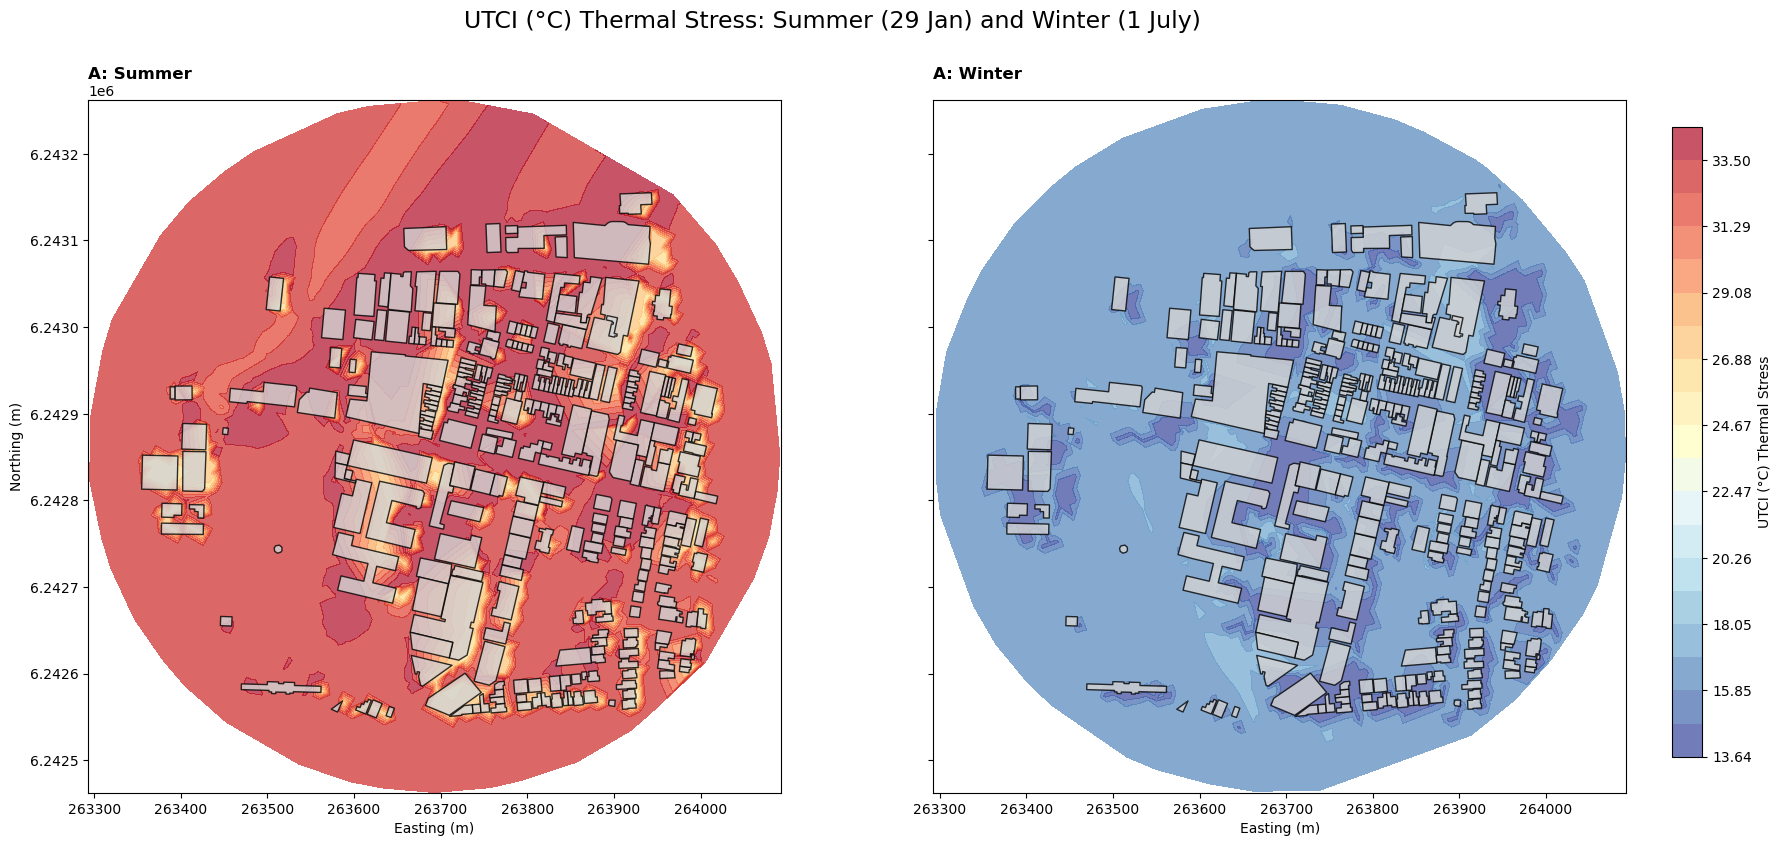

In [78]:
fig, axes = city3D.plot_utci(summer10m_df, winter10m_df, ts_copy, utm_gdf.geometry[0].x, utm_gdf.geometry[0].y, radius=400, 
                          title_suffix="UTCI (°C) Thermal Stress: Summer (29 Jan) and Winter (1 July)")
plt.show()

<div class="alert alert-block alert-success"><b>QUESTION</b>

Why do we / is the *'gold standard'* UTCI formula calibated to use the wind at 10m but evaluates solar radiation and Thermal Comfort at ground level? 
</div>

**UTCI categories can be interpreted as follows:**

| UTCI Range (°C) | Category | Colour Map |
| :---: | :---: | :--- |
| > 38 | Very Strong Heat Stress | Dark Red | 
| 28- 30 | Strong Heat Stress | Orange/Red | 
| 26 - 32 | Moderate Heat Stress | Yellow/Orange |
| 9 - 26 | Thermal Comfort|	Blue/Yellow |

<div class="alert alert-block alert-info"><b>UTCI in the Cold Range</b> 

Because UTCI is a ***universal*** index it covers the entire spectrum from −50°C to +50°C. In winter, we simply shift to the blue end of the scale.

</div>

| UTCI Range (°C) | Category | Human Sensation |
| :---: | :---: | :--- |
| 9 - 0 | Slight Cold Stress | You need a jacket; extremities feel cool. | 
| 0- -13 | Moderate Cold Stress | Risk of hypothermia over long exposure. | 
| -13 - -27 | Strong Cold Stress | High discomfort; shivering starts. |

### c. Wind Chill Temperature Index

<div class="alert alert-block alert-warning"><b></b>
    
Generally weather services don't use the UTCI in the cold range but a [Wind Chill Temperature Index](https://en.wikipedia.org/wiki/Wind_chill) which focuses strictly on how the wind "strips" heat from the skin.  
Several standard wind chill formula exist, we execute the one adopted by [Environment Canada](https://www.canada.ca/en/services/environment/weather/severeweather/wind-chill-index.html):  

$$ WCI = 13.12 + 0.6215 * {T}_{a} −11.37 * {v}^{0.16} + 0.3965 * {T}_{a} * {v}^{0.16}  $$

</div>

In [79]:
#- calculate wind chill

# m/s to kh/m
v_kmh = winter10m_df['U10_equivalent'] * 3.6
# raise to the power 0.16
v16 = v_kmh**0.16

winter10m_df['wind_chill'] = (
    13.12 + (0.6215 * Wta) - 
    (11.37 * v16) + (0.3965 * Wta * v16)
)
winter10m_df.head(2)

,X,Y,Z,U,V,u_mag,k,R,lawson_class,U10_equivalent,is_shaded,u_mag_10m,utci,wind_chill
0,263489.184240,6.242593e+06,1.5,0.308725,-0.540327,0.622793,0.576419,0.090260,Sitting/Long-term (Outdoor Dining),1.534900,False,1.534900,16.95,14.171561
1,263486.471592,6.242592e+06,1.5,0.229228,-0.597535,0.640002,0.599802,0.092754,Sitting/Long-term (Outdoor Dining),1.577314,False,1.577314,16.94,14.138126


In [1]:
def plot_windChill(ped_df, buildings_df, center_x_utm, center_y_utm, radius=400):
    """
    Generates a side-by-side Velocity Magnitude and Vector Flow plot.
    center_coords: tuple (center_x_utm, center_y_utm)
    """
    #cx, cy = center_coords
    
    # 1. Setup the figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9), sharey=True)

    # --- MAP A: Magnitude (Tricontour) ---
    cntr = ax1.tricontourf(ped_df['X'], ped_df['Y'], ped_df['wind_chill'], 
                           levels=20, cmap='jet', alpha=0.7)
    
    # Use your existing plot_geometries function
    city3D.plot_geometries(buildings_df, ax=ax1, facecolor='lightgrey', edgecolor='black', alpha=0.8)
    ax1.set_title('A: Wind Chill Magnitude (°C)', loc='left', pad=15, weight='bold')

    # --- MAP B: Flow (Quiver) ---
    QUIVsampled_df = ped_df.iloc[::1].copy()
    # Check column names after build_utci_layer merge step
    # (Remaps 'U10_equivalent' to 'u_mag_10m')
    mag_col = 'u_mag_10m' if 'u_mag_10m' in QUIVsampled_df.columns else 'U10_equivalent'
    
    # 1. Back-calculate the reduction multiplier for this specific layer
    # Since: u_mag_10m = u_mag / r_dynamic
    # We can scale the directional velocity vectors proportionally:
    scale_factor = QUIVsampled_df[mag_col] / QUIVsampled_df['u_mag']
    
    # Handle any potential division by zero in zero-wind locations safely
    scale_factor = scale_factor.fillna(1.0)
    
    u_10m = QUIVsampled_df['U'] * scale_factor
    v_10m = QUIVsampled_df['V'] * scale_factor
    # Plot binned_df instead of the raw 10M rows
    qv = ax2.quiver(QUIVsampled_df['X'], QUIVsampled_df['Y'], QUIVsampled_df['U'], QUIVsampled_df['V'], QUIVsampled_df['wind_chill'], cmap='jet',
                    scale=120, alpha=0.9, width=0.003)
    #qv = ax2.quiver(x, y, u, v, mags, cmap='jet', scale=120, alpha=0.9, width=0.003)
    
    city3D.plot_geometries(buildings_df, ax=ax2, facecolor='lightgrey', edgecolor='black', alpha=0.8)
    ax2.set_title('B: Vector Flow Field', loc='left', pad=15, weight='bold')

    # --- AXIS & SPATIAL STYLING ---
    for ax in [ax1, ax2]:
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('Easting (m)')
        # Force strict 400m AOI
        ax.set_xlim(center_x_utm - radius, center_x_utm + radius)
        ax.set_ylim(center_y_utm - radius, center_y_utm + radius)

    ax1.set_ylabel('Northing (m)')

    # --- SHARED COLORBAR (The "No Squish" Fix) ---
    fig.subplots_adjust(right=0.9) 
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) 
    fig.colorbar(cntr, cax=cbar_ax, label='Wind Chill Index')

    plt.suptitle(f'Wind Chill Temperature Index', fontsize=16, y=0.98)
    
    return fig, (ax1, ax2)

fig, axes = plot_windChill(winter10m_df, ts_copy, utm_gdf.geometry[0].x, utm_gdf.geometry[0].y)
plt.show()

NameError: name 'winter10m_df' is not defined

<div class="alert alert-block alert-danger"><b>Disclaimer</b>

These [UTCI](https://www.utci.org) metrics and maps are a Climatological Approximation. 

It uses [CFD](https://en.wikipedia.org/wiki/Computational_fluid_dynamics)-derived wind speeds combined with local solar geometry. While it accurately identifies [wind-chill](https://en.wikipedia.org/wiki/Wind_chill) and sun-scorched areas, a Robust [**Heat-Transfer Simulation**](https://www.simscale.com/docs/analysis-types/heat-transfer/) would be required to model the 'thermal flywheel' effect of building materials *(how concrete [roads, earth, etc.] stays hot, and release heat, after the sun goes down)*

## 2. Possible Secondary and Tertiary level conversations starters
<div class="alert alert-block alert-success"><b> exchange knowledge and understanding</b></div>

| **Topic** | **Secondary Level Questions** | **Tertiary Level Questions** |
|----------|------------------------------|------------------------------|
| **Feeling the Wind in Place** | - When you walk in this area, where do you feel the wind the most?<br>- Are there places that feel calm or sheltered?<br>- How does the wind change between streets, corners, and open spaces? | - How do the simulation results compare with your own experience of wind in this area?<br>- What features of the built environment (e.g., building height, street width) might explain these differences?<br>- How could local knowledge help improve or validate the simulation? |
| **Streets, Buildings & Wind** | - How do buildings change the way wind moves through the neighborhood?<br>- Do narrow streets feel different from wide streets in terms of wind?<br>- Where do you think wind speeds up or slows down? | - Identify patterns in the simulation where wind is channelled, blocked, or redirected.<br>- How does the arrangement of buildings shape these patterns?<br>- What might this mean for how the area was designed or developed? |
| **Comfort in Everyday Spaces** | - Which places in the area feel comfortable to stand, sit, or walk in?<br>- Are there places that feel too windy or exposed?<br>- How might this affect how people use public spaces? | - Using the simulation, identify areas that may be uncomfortable for pedestrians.<br>- How could these conditions affect different groups of people (e.g., elderly, children)?<br>- What small changes could make these spaces more comfortable? |
| **Wind, Temperature & How We Feel** | - Why does a windy day sometimes feel colder than it actually is?<br>- How do sun, shade, and wind together affect how a place feels?<br>- Where in the area might feel warmer or cooler? | - How can wind speed influence perceived temperature (e.g., wind chill or thermal comfort)?<br>- How might combining wind data with weather conditions change our understanding of comfort?<br>- What kinds of places might be most affected during very hot or cold days? |
| **Comparing Places** | - Compare two different spots in the area: how does the wind feel different?<br>- What makes one place feel more comfortable than another?<br>- How might people choose where to walk or spend time based on this? | - Use the simulation to compare wind conditions across different locations.<br>- What spatial patterns emerge (e.g., exposed vs sheltered zones)?<br>- How could this influence movement, activity, or land use in the area? |
| **Improving Local Spaces** | - What changes could make windy areas more comfortable?<br>- Could trees, walls, or different building layouts help?<br>- Where would you suggest making improvements? | - Test or propose design changes based on the simulation results.<br>- How might interventions (e.g., vegetation, barriers) change wind patterns?<br>- What trade-offs might exist between airflow (cooling) and comfort? |
| **People, Place & Environment** | - How does wind affect daily life in this neighborhood?<br>- Are there times of year when wind is more noticeable?<br>- How might different people experience these conditions differently? | - How can understanding wind and comfort support better public space design?<br>- What role can local communities play in identifying environmental challenges?<br>- How could this analysis support more inclusive and livable urban spaces? |
| **Understanding the Model** | - What do you think this simulation is showing?<br>- What information do we need to model wind in a place like this?<br>- Why might the model not match reality exactly? | - What are the limitations of this type of simulation?<br>- How sensitive are results to inputs like wind direction or building data?<br>- How could field observations be used to improve the model? |